## Lab 2

### 1. Library Imports

In [1]:
# tensorflow must be imported before pandas/sklearn, otherwise the MKL that they
# load first breaks TF's GPU variable allocation and the kernel segfaults
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1786364297.047251  232504 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786364297.078574  232504 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2. Task 1: TensorFlow Playground

The playground itself is a website, so the notes below record what the experiments show.
The spiral dataset with only the two raw features $x_1$ and $x_2$ needs about 4 hidden
layers of 8 neurons. With the default tanh activation it trains very slowly and sits on
plateaus for long stretches, which is the vanishing gradients problem: tanh saturates, its
gradient is near zero there, and with 4 layers the gradient that reaches the first layer is
tiny.

The same network is reproduced below so the effect can be seen directly, comparing the
playground's default (tanh with Glorot initialisation) against ReLU with He initialisation.

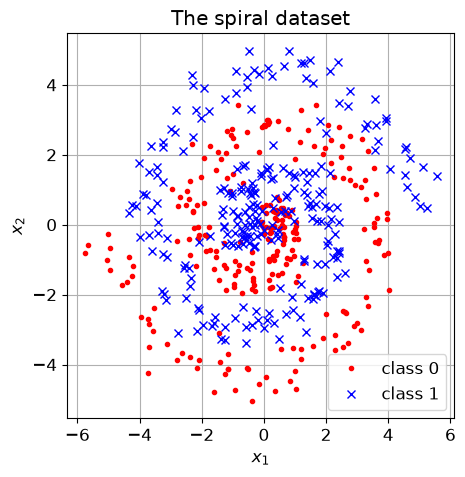

In [2]:
def make_spiral(n_points=500, noise=0.4, seed=42):
    rng = np.random.default_rng(seed)
    n = n_points // 2
    i = np.arange(n)
    r = i / n * 5
    t = 1.75 * i / n * 2 * np.pi
    X = np.concatenate([
        np.c_[r * np.sin(t), r * np.cos(t)],
        np.c_[-r * np.sin(t), -r * np.cos(t)],
    ])
    X += rng.normal(scale=noise, size=X.shape)
    y = np.concatenate([np.zeros(n), np.ones(n)])
    return X.astype("float32"), y.astype("float32")


X_spiral, y_spiral = make_spiral()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1], "r.", label="class 0")
ax.plot(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1], "bx", label="class 1")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("The spiral dataset")
ax.legend()
ax.grid(True)
plt.show()

In [3]:
def build_spiral_model(activation, initializer):
    tf.random.set_seed(42)
    model = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=[2])])
    for _ in range(4):  # 4 hidden layers of 8 neurons, as on the playground
        model.add(tf.keras.layers.Dense(8, activation=activation,
                                        kernel_initializer=initializer))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy",
                  optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
                  metrics=["accuracy"])
    return model


histories = {}
for name, activation, initializer in [("tanh + Glorot", "tanh", "glorot_uniform"),
                                      ("relu + He", "relu", "he_normal")]:
    model = build_spiral_model(activation, initializer)
    histories[name] = model.fit(X_spiral, y_spiral, epochs=300, verbose=0)
    print(f"{name:14s} final training accuracy: "
          f"{histories[name].history['accuracy'][-1]:.3f}")

I0000 00:00:1786364299.200681  232504 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


I0000 00:00:1786364300.063518  232582 service.cc:153] XLA service 0x74b7a002f620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786364300.063537  232582 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0000 00:00:1786364300.071468  232582 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786364300.125724  232582 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1786364300.129973  232582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_790__.11


I0000 00:00:1786364301.341355  232582 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1786364301.498950  232581 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_790__.11


tanh + Glorot  final training accuracy: 0.698


I0000 00:00:1786364315.745254  232580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24408__.11


I0000 00:00:1786364316.316465  232580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24408__.11


relu + He      final training accuracy: 0.810


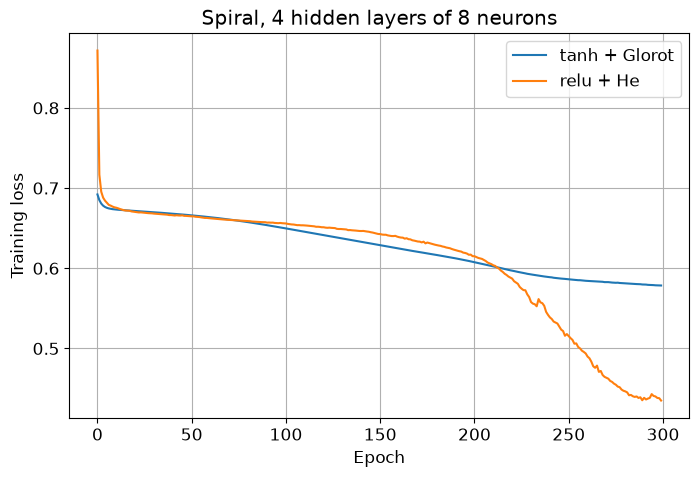

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, history in histories.items():
    ax.plot(history.history["loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Spiral, 4 hidden layers of 8 neurons")
ax.legend()
ax.grid(True)
plt.show()

The tanh curve stays flat for a long time before it starts to move, which is the plateau
seen on the playground. Swapping to ReLU with He initialisation keeps the gradients alive
and the loss drops much sooner. This is what Chapter 11 addresses with better
initialisation, non-saturating activations, and better optimizers.

### 3. Task 2: Fashion MNIST, Splitting into Tasks A and B

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = \
    tf.keras.datasets.fashion_mnist.load_data()

X_train, y_train = X_train_full[:-5000] / 255., y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:] / 255., y_train_full[-5000:]
X_test = X_test / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(X_train.shape, X_valid.shape, X_test.shape)

(55000, 28, 28) (5000, 28, 28) (10000, 28, 28)


Task A is the 8 classes that are not T-shirt/top or Pullover. Task B is a binary
classification between those two, with only 200 training images.

In [6]:
pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")


def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))


(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

print(X_train_A.shape, X_train_B.shape)

(44011, 28, 28) (200, 28, 28)


### 4. Task 2: Training Model A

In [7]:
tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A), verbose=0)

model_A.save("my_model_A.keras")
print("model A validation accuracy:", history.history["val_accuracy"][-1])

I0000 00:00:1786364332.511348  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47857__.14


I0000 00:00:1786364336.041561  232580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47857__.14


model A validation accuracy: 0.9072449207305908


### 5. Task 2: Model B Without Reusing Model A

In [8]:
tf.random.set_seed(42)

model_B = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

history_B = model_B.fit(X_train_B, y_train_B, epochs=20,
                        validation_data=(X_valid_B, y_valid_B), verbose=0)

acc_B = model_B.evaluate(X_test_B, y_test_B, verbose=0)[1]
print("model B test accuracy:", acc_B)

I0000 00:00:1786364382.725345  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_169427__.10


I0000 00:00:1786364383.122878  232581 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_169427__.10
I0000 00:00:1786364383.283454  261974 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 20 bytes spill stores, 32 bytes spill loads

I0000 00:00:1786364383.291047  261976 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 4 bytes spill stores, 4 bytes spill loads



model B test accuracy: 0.9024999737739563


### 6. Task 2: Model B on A

`model_B_on_A` reuses all of model A's layers except its output layer. Model A is cloned
first, otherwise the two models would share layers and training one would modify the other.
The reused layers are frozen for the first 4 epochs so the new output layer can settle,
then everything is unfrozen for 16 more epochs at a low learning rate.

In [9]:
model_A = tf.keras.models.load_model("my_model_A.keras")

model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [10]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B), verbose=0)

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B), verbose=0)

acc_B_on_A = model_B_on_A.evaluate(X_test_B, y_test_B, verbose=0)[1]
print("model B on A test accuracy:", acc_B_on_A)

I0000 00:00:1786364389.508832  232581 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176110__.10


I0000 00:00:1786364389.850990  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176110__.10


model B on A test accuracy: 0.9369999766349792


In [11]:
error_drop = 1 - (1 - acc_B_on_A) / (1 - acc_B)

pd.DataFrame([
    {"model": "model B (from scratch)", "test accuracy": acc_B},
    {"model": "model B on A (transfer)", "test accuracy": acc_B_on_A},
]).set_index("model").round(4)

,test accuracy
model,
model B (from scratch),0.9025
model B on A (transfer),0.9370


In [12]:
print(f"error rate dropped by {error_drop:.1%}")

error rate dropped by 35.4%


### 7. Task 2: Comparing Optimizers

Each optimizer trains the same architecture on the full Fashion MNIST training set for
10 epochs, using the hyperparameters from Chapter 11.

In [13]:
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[28, 28]),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])


def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid), verbose=0)

In [14]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.001),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                        nesterov=True),
    "AdaGrad": tf.keras.optimizers.Adagrad(learning_rate=0.001),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    "AdaMax": tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    "Nadam": tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    "AdamW": tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                       beta_1=0.9, beta_2=0.999),
}

optimizer_histories = {}
for name, optimizer in optimizers.items():
    optimizer_histories[name] = build_and_train_model(optimizer)
    print(f"{name:9s} val_accuracy: "
          f"{optimizer_histories[name].history['val_accuracy'][-1]:.4f}")

I0000 00:00:1786364393.886728  232582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_180220__.14


I0000 00:00:1786364397.322026  232580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_180220__.14


SGD       val_accuracy: 0.8328


I0000 00:00:1786364426.515057  232581 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256648__.14


I0000 00:00:1786364429.578294  232580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256648__.14


...

I0000 00:00:1786364919.137001  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_717838__.14


Nadam     val_accuracy: 0.8692


I0000 00:00:1786364983.264534  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_795012__.14


I0000 00:00:1786364996.027290  232582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_795012__.14


AdamW     val_accuracy: 0.8684


In [15]:
results = pd.DataFrame([
    {"optimizer": name,
     "val accuracy": h.history["val_accuracy"][-1],
     "val loss": h.history["val_loss"][-1]}
    for name, h in optimizer_histories.items()
]).set_index("optimizer").sort_values("val accuracy", ascending=False)

results.round(4)

,val accuracy,val loss
optimizer,,
Adam,0.8806,0.3897
AdaMax,0.8768,0.3303
Nadam,0.8692,0.4018
AdamW,0.8684,0.3973
Nesterov,0.8676,0.3622
Momentum,0.8630,0.3605
RMSProp,0.8492,0.5645
AdaGrad,0.8408,0.4484
SGD,0.8328,0.4668


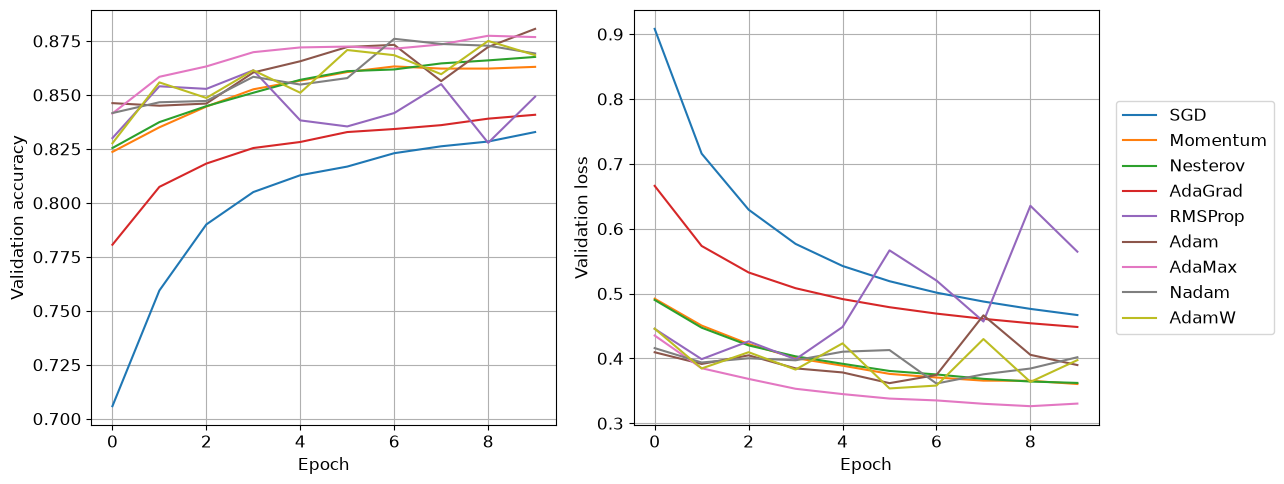

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, h in optimizer_histories.items():
    axes[0].plot(h.history["val_accuracy"], label=name)
    axes[1].plot(h.history["val_loss"], label=name)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation loss")
for ax in axes:
    ax.grid(True)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

Adam finishes highest at 88.1% validation accuracy, with AdaMax just behind at 87.7% but on
the lowest validation loss of the group. The three plain SGD variants sit at the bottom,
and adding momentum (86.3%) then Nesterov (86.8%) recovers a good part of the gap over
plain SGD (83.3%). The ordering matches Chapter 11: the adaptive methods reach a decent
solution in far fewer epochs, which is what matters when only 10 epochs are allowed.

RMSProp (84.9%) and AdaGrad (84.1%) do poorly here, but that is a learning rate artifact
rather than a property of the algorithms. Every optimizer is being run at the same
`learning_rate=0.001` for comparability, and that is well below what those two want.

### 8. Task 3: MNIST, Finding the Learning Rate

In [17]:
(X_train_full, y_train_full), (X_test, y_test) = \
    tf.keras.datasets.mnist.load_data()

X_train, y_train = X_train_full[:-5000] / 255., y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:] / 255., y_train_full[-5000:]
X_test = X_test / 255.

print(X_train.shape, X_valid.shape, X_test.shape)

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   24576/11490434 ━━━━━━━━━━━━━━━━━━━━ 24s 2us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 35s 3us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 41s 4us/step

  147456/11490434 ━━━━━━━━━━━━━━━━━━━━ 27s 2us/step

...

 8257536/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 9601024/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11059200/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


(55000, 28, 28) (5000, 28, 28) (10000, 28, 28)


The callback below grows the learning rate by 0.5% at every batch and records the loss,
so a single epoch is enough to see where training becomes unstable.

In [18]:
class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [19]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

expon_lr = ExponentialLearningRate(factor=1.005)
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr], verbose=0)

I0000 00:00:1786365030.598343  232582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_871123__.13


I0000 00:00:1786365036.274979  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_871123__.13


I0000 00:00:1786365036.478130  414960 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 20 bytes spill stores, 20 bytes spill loads



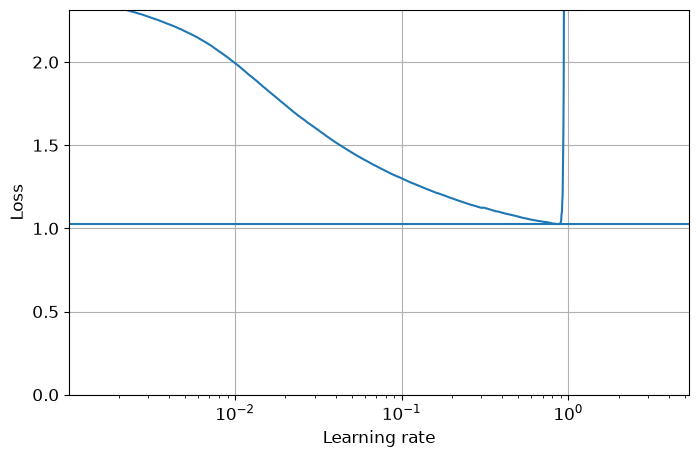

learning rate at minimum loss: 0.870


In [20]:
plt.figure(figsize=(8, 5))
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale("log")
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.show()

best_rate = expon_lr.rates[np.argmin(expon_lr.losses)]
print(f"learning rate at minimum loss: {best_rate:.3f}")

### 9. Task 3: Training with Early Stopping and TensorBoard

The range test above puts the minimum loss near a learning rate of 0.87, with the curve
climbing steeply after that. Following the Chapter 10 rule of thumb of backing well off the
point where the loss shoots up, 3e-1 is used for training below.

In [21]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=3e-1),
              metrics=["accuracy"])

In [22]:
run_index = 1  # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras",
                                                   save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb],
                    verbose=0)

print("epochs actually run:", len(history.history["loss"]))

I0000 00:00:1786365039.790644  232582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_884609__.13


I0000 00:00:1786365046.363788  232583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_884609__.13


epochs actually run: 22


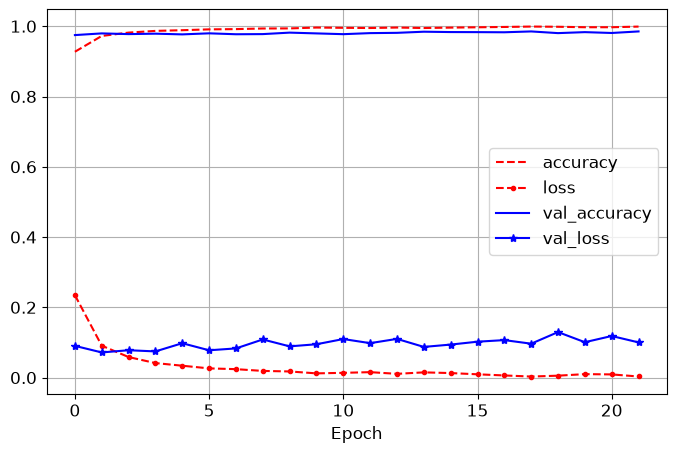

In [23]:
pd.DataFrame(history.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                   style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [24]:
model = tf.keras.models.load_model("my_mnist_model.keras")  # roll back to best model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"test accuracy: {test_acc:.4f}")

test accuracy: 0.9737


The TensorBoard logs are written to `my_mnist_logs/`. To view them, run

```bash
tensorboard --logdir=./my_mnist_logs
```

from the `lab2` directory, or load the extension in the notebook with
`%load_ext tensorboard` and `%tensorboard --logdir=./my_mnist_logs`.

The model reaches **97.4%** test accuracy. Early stopping halted training after 22 epochs,
meaning the best validation loss came early and 20 further epochs failed to beat it.

That is a little under the 98% the exercise asks for. The cause is the learning rate: 3e-1
trains fast but is aggressive enough that the model bounces around its best solution
instead of settling into it, which is why the best checkpoint lands so early. Training
longer does not help while the learning rate stays this high. Closing the gap would mean
either a smaller learning rate over more epochs, a learning rate schedule to decay it as
training progresses (Chapter 11 covers these), or one of the adaptive optimizers that came
out ahead in Task 2.